In [7]:
import pandas as pd
import numpy as np

In [8]:
gradient_data = pd.read_parquet(
    "../data/processed/gradient_data.parquet"
)

In [9]:
gradient_data.columns

Index(['timestamp', 'ws100', 'wd100', 'wd10', 'wind_shear',
       'relative_humidity', 'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'CAPACITY_FACTOR',
       'ND', 'wd100_sin', 'ws100_cos', 'wd10_sin', 'wd10_cos', 'hour',
       'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'ws100_lag_1', 'ws100_lag_24',
       'wind_shear_lag_1', 'wind_shear_lag_24', 'i10fg_lag_1', 'i10fg_lag_24',
       'relative_humidity_lag_1', 'relative_humidity_lag_24',
       'air_density_lag_1', 'air_density_lag_24', 'blh_lag_1', 'blh_lag_24',
       'tcc_lag_1', 'tcc_lag_24', 'tp_lag_1', 'tp_lag_24', 'ws100_lag_168',
       'gen_lag_1', 'gen_lag_24', 'gen_lag_168', 'ws100_roll_mean_6',
       'ws100_roll_mean_24', 'ws100_roll_std_6', 'ws100_roll_std_24',
       'EMBEDDED_WIND_GENERATION_roll_mean_6',
       'EMBEDDED_WIND_GENERATION_roll_mean_24',
       'EMBEDDED_WIND_GENERATION_roll_std_6',


In [71]:
rnn_data = pd.read_parquet(
    "../data/processed/rnn_data.parquet"
)

<h1>XGBoost

In [ ]:
X = gradient_data.drop(columns=["EMBEDDED_WIND_GENERATION", "timestamp", "CAPACITY_FACTOR", "gen_lag_1", "EMBEDDED_WIND_GENERATION_roll_mean_6", "EMBEDDED_WIND_GENERATION_roll_mean_24", "EMBEDDED_WIND_GENERATION_roll_std_6" ,"EMBEDDED_WIND_GENERATION_roll_std_24"])
y = gradient_data["EMBEDDED_WIND_GENERATION"]

In [12]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

In [13]:
print(X_train.dtypes.unique())

[dtype('float64') dtype('int32')]


In [14]:
print(X.columns)

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg',
       'EMBEDDED_WIND_CAPACITY', 'ND', 'wd100_sin', 'ws100_cos', 'wd10_sin',
       'wd10_cos', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'ws100_lag_1', 'ws100_lag_24',
       'wind_shear_lag_1', 'wind_shear_lag_24', 'i10fg_lag_1', 'i10fg_lag_24',
       'relative_humidity_lag_1', 'relative_humidity_lag_24',
       'air_density_lag_1', 'air_density_lag_24', 'blh_lag_1', 'blh_lag_24',
       'tcc_lag_1', 'tcc_lag_24', 'tp_lag_1', 'tp_lag_24', 'ws100_lag_168',
       'gen_lag_24', 'gen_lag_168', 'ws100_roll_mean_6', 'ws100_roll_mean_24',
       'ws100_roll_std_6', 'ws100_roll_std_24'],
      dtype='object')


In [15]:
print("train", X_train.shape)
print("val", X_val.shape)
print("test", X_test.shape)

train (48966, 48)
val (10492, 48)
test (10494, 48)


In [16]:
#hyper parameter tuning
from sklearn.model_selection import TimeSeriesSplit

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
#!pip install xgboost

<h1> basic model

In [14]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred = xgb.predict(X_test)

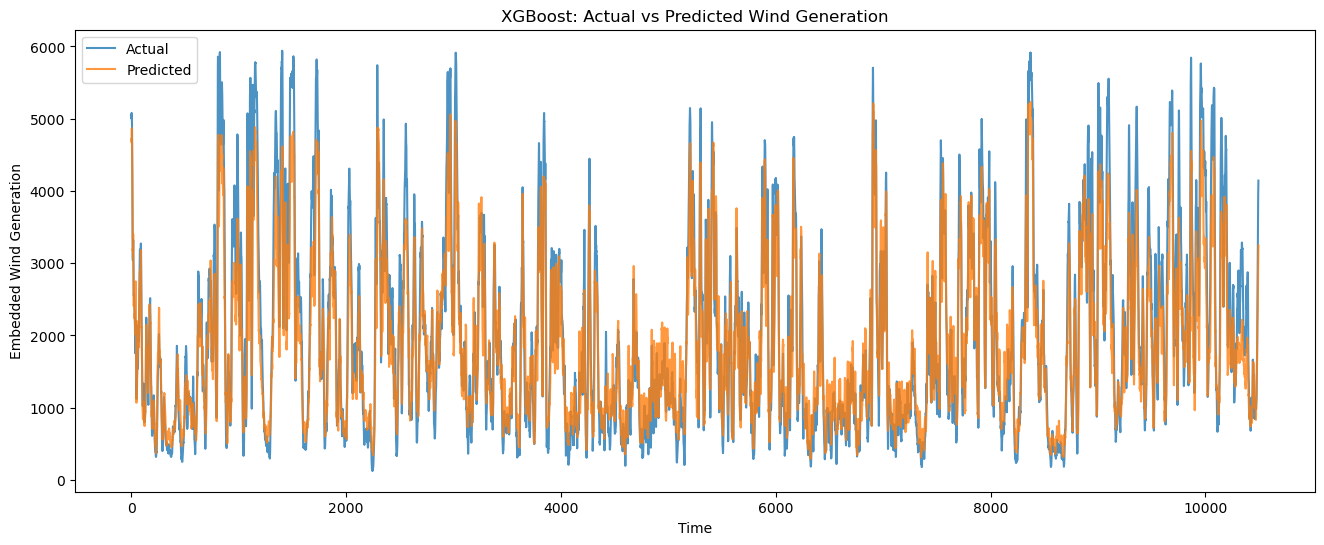

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [17]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_results = results.copy()

In [223]:
xg_results.to_csv(
    "../data/results/xg_results.csv",
    index=False
)

In [18]:
xg_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59458,2024-10-20 17:00:00,5043.0,4717.180176,325.819824,325.819824
59459,2024-10-20 18:00:00,5041.0,4695.134766,345.865234,345.865234
59460,2024-10-20 19:00:00,5002.5,4718.444824,284.055176,284.055176
59461,2024-10-20 20:00:00,5048.5,4671.136719,377.363281,377.363281
59462,2024-10-20 21:00:00,5067.5,4674.483398,393.016602,393.016602
...,...,...,...,...,...
69947,2025-12-31 19:00:00,3471.5,2821.152588,650.347412,650.347412
69948,2025-12-31 20:00:00,3746.0,2914.897949,831.102051,831.102051
69949,2025-12-31 21:00:00,3948.0,2999.343994,948.656006,948.656006
69950,2025-12-31 22:00:00,4043.0,3130.420898,912.579102,912.579102


<h2> evaluation matrics

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_val_pred = xgb.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)

mse = mean_squared_error(y_val, y_val_pred)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  200.5403
RMSE:  260.4162
R2:  0.9513


<h3>feature importance

In [27]:
importance_df.sort_values(
    "Importance",
    ascending=False
).head(60)

,Feature,Importance
10,i10fg,0.766384
0,ws100,0.130560
29,i10fg_lag_1,0.024406
9,ssrd,0.014918
11,EMBEDDED_WIND_CAPACITY,0.004488
17,hour,0.004196
24,month_cos,0.003458
1,wd100,0.002977
3,wind_shear,0.002660
37,tcc_lag_1,0.002610


i10fg domates ws100
suggesting it is very higly correlated with generation

most engineered lag features are weak indicating that current atmospheric conditions have greater contributions compared to historical atmospheric conditions

wd10_cos literally 0 importance can remove it. 

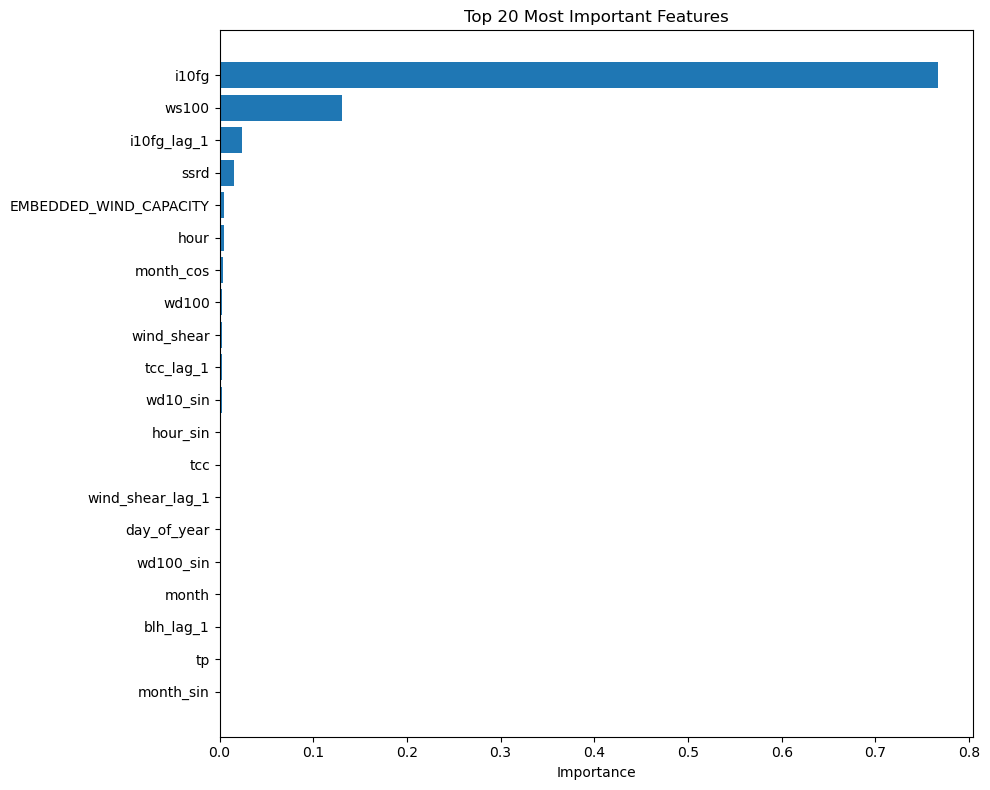

In [21]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [23]:
param_dist = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

n_estimator = number of trees, 100 baseline, 300 moderate, 500 commonly used and 700 aggressive
max_depth = how deep trees grow simple, moderate and complex
subsample = controls how much training data each trees see
colsample_bytree = controls how many features each tree can use

<h2>tuned model

In [ ]:
xgb_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 300, 500, 700],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [230]:
y_tuned_pred = xgb_tuned.predict(X_test)

In [236]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_tuned_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_tuned_results = results.copy()

In [237]:
xg_tuned_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59458,2024-10-20 17:00:00,5043.0,4778.858887,264.141113,264.141113
59459,2024-10-20 18:00:00,5041.0,4854.763672,186.236328,186.236328
59460,2024-10-20 19:00:00,5002.5,4755.392578,247.107422,247.107422
59461,2024-10-20 20:00:00,5048.5,4763.836426,284.663574,284.663574
59462,2024-10-20 21:00:00,5067.5,4772.176758,295.323242,295.323242
...,...,...,...,...,...
69947,2025-12-31 19:00:00,3471.5,2815.201172,656.298828,656.298828
69948,2025-12-31 20:00:00,3746.0,2840.571777,905.428223,905.428223
69949,2025-12-31 21:00:00,3948.0,2946.456787,1001.543213,1001.543213
69950,2025-12-31 22:00:00,4043.0,3109.705322,933.294678,933.294678


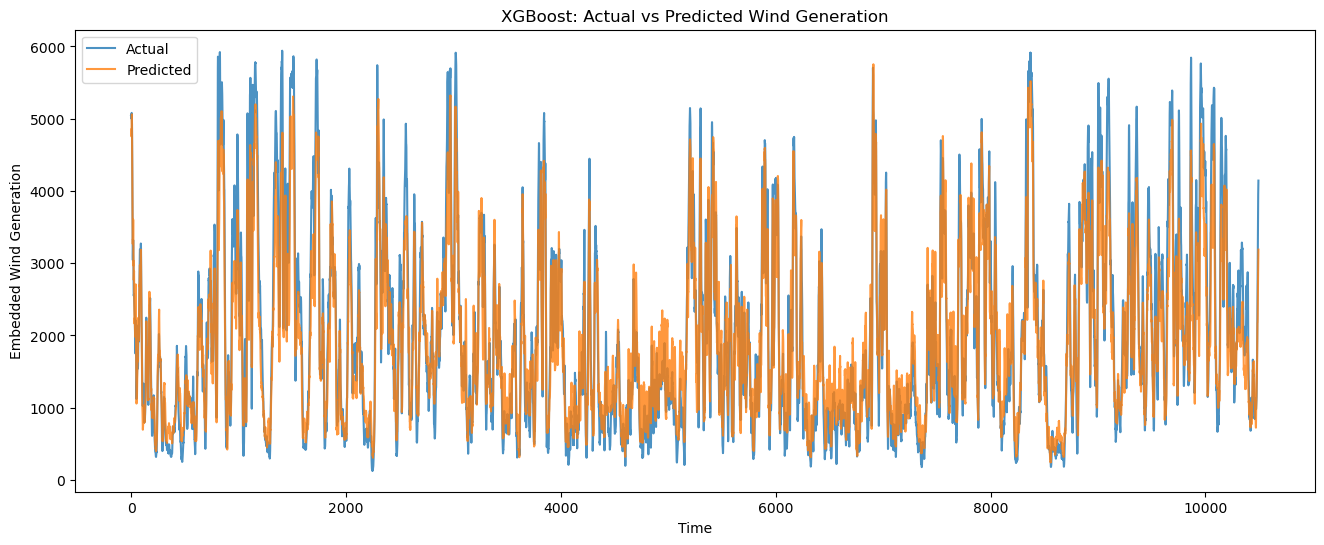

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_tuned_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [234]:
best_xgb = xgb_tuned.best_estimator_

y_val_pred_tuned = best_xgb.predict(X_val)

In [238]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_tuned)

mse = mean_squared_error(y_val, y_val_pred_tuned)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_tuned)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  218.1611
RMSE:  278.5430
R2:  0.9443


In [240]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
10,i10fg,0.581098
0,ws100,0.299325
29,i10fg_lag_1,0.031858
9,ssrd,0.027588
11,EMBEDDED_WIND_CAPACITY,0.006318
1,wd100,0.004074
17,hour,0.003057
27,wind_shear_lag_1,0.002626
37,tcc_lag_1,0.002262
7,tcc,0.002033


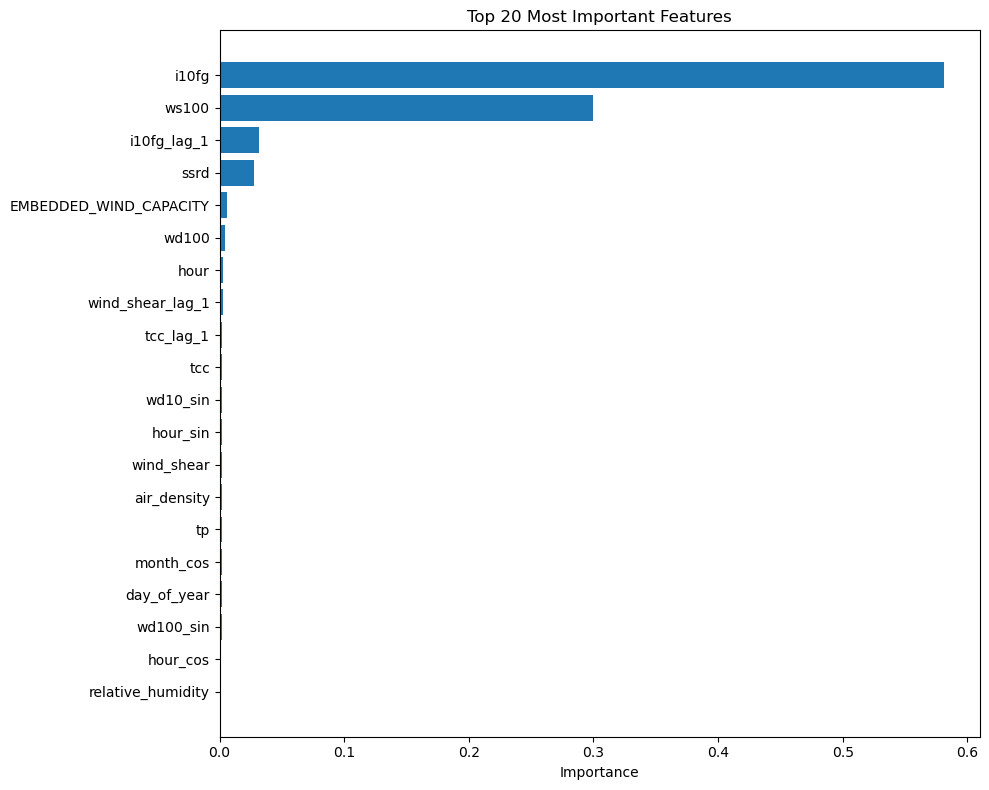

In [241]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
#import shap

#explainer = shap.TreeExplainer(xgb)

#shap_values = explainer.shap_values(X_test)

#shap.summary_plot(
#    shap_values,
#    X_test
#)

<h1>lightBGM

In [ ]:
#!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 10.1 MB/s eta 0:00:00


In [20]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10333
[LightGBM] [Info] Number of data points in the train set: 48966, number of used features: 48
[LightGBM] [Info] Start training from score 1801.617954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMRegressor(max_depth=6, random_state=42)

In [21]:
y_val_pred_lgbm = lgbm.predict(X_val)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_lgbm)

mse = mean_squared_error(y_val, y_val_pred_lgbm)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_lgbm)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  202.1267
RMSE:  259.7620
R2:  0.9515


In [28]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
})

importance_df.sort_values(
    "Importance",
    ascending=False
).head(60)

,Feature,Importance
20,day_of_year,226
0,ws100,217
11,EMBEDDED_WIND_CAPACITY,207
1,wd100,190
9,ssrd,150
10,i10fg,117
2,wd10,88
12,ND,81
42,gen_lag_24,80
45,ws100_roll_mean_24,76


In [22]:
y_lgbm_pred = lgbm.predict(X_test)

In [23]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_lgbm_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

lgbm_results = results.copy()

In [24]:
lgbm_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59458,2024-10-20 17:00:00,5043.0,5185.268122,-142.268122,142.268122
59459,2024-10-20 18:00:00,5041.0,5117.274352,-76.274352,76.274352
59460,2024-10-20 19:00:00,5002.5,5044.457603,-41.957603,41.957603
59461,2024-10-20 20:00:00,5048.5,5081.568930,-33.068930,33.068930
59462,2024-10-20 21:00:00,5067.5,5110.952053,-43.452053,43.452053
...,...,...,...,...,...
69947,2025-12-31 19:00:00,3471.5,2913.660177,557.839823,557.839823
69948,2025-12-31 20:00:00,3746.0,3009.587333,736.412667,736.412667
69949,2025-12-31 21:00:00,3948.0,3036.681352,911.318648,911.318648
69950,2025-12-31 22:00:00,4043.0,3112.179349,930.820651,930.820651


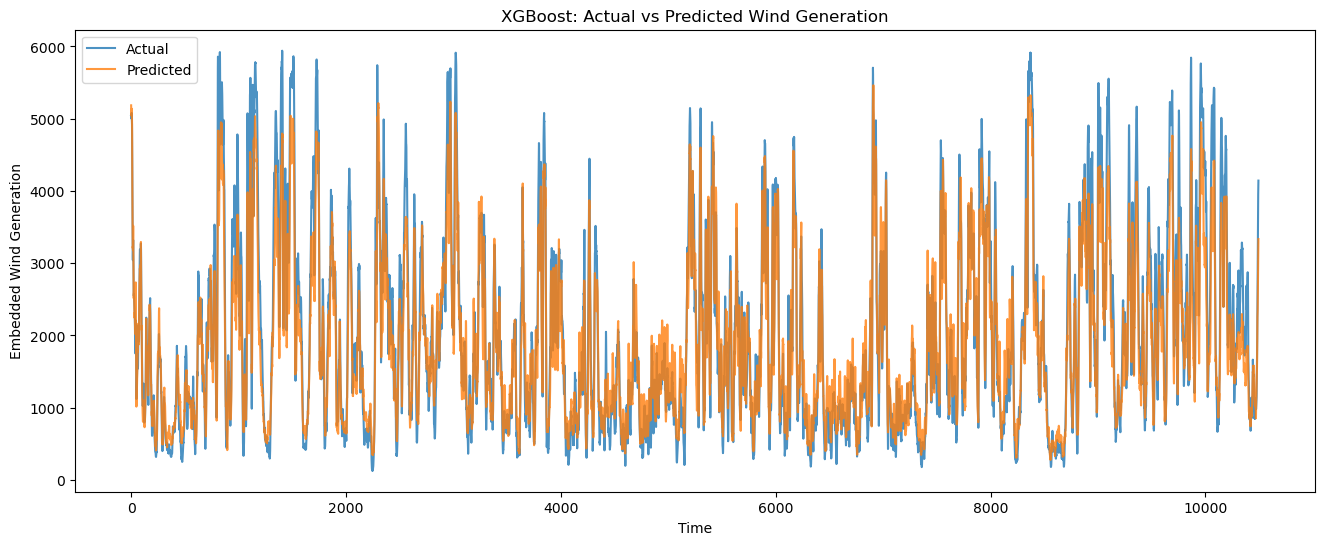

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_lgbm_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

<h2>tuned lightBGM

In [29]:
param_dist = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [32]:
lgbm_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\LOQ\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:52:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 300, 500, 700],
                                        'num_leaves': [31, 50, 70, 100],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [33]:
y_val_pred_lgbm_tuned = lgbm_tuned.predict(X_val)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_lgbm_tuned)

mse = mean_squared_error(y_val, y_val_pred_lgbm_tuned)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_lgbm_tuned)
print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  204.8322
RMSE:  262.7609
R2:  0.9504


<h1>LSTM

In [82]:
rnn_data.columns

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'CAPACITY_FACTOR',
       'ND', 'wd100_sin', 'ws100_cos', 'wd10_sin', 'wd10_cos', 'hour',
       'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'wd100_cos'],
      dtype='object')

In [85]:
X = rnn_data.drop(columns=["EMBEDDED_WIND_GENERATION", "CAPACITY_FACTOR", "ND"])
y = rnn_data["EMBEDDED_WIND_GENERATION"]

In [86]:
X.columns

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg',
       'EMBEDDED_WIND_CAPACITY', 'wd100_sin', 'ws100_cos', 'wd10_sin',
       'wd10_cos', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'wd100_cos'],
      dtype='object')

In [87]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

In [88]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_val_scaled = feature_scaler.transform(X_val)

X_test_scaled = feature_scaler.transform(X_test)

In [89]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_val_scaled = target_scaler.transform(
    y_val.values.reshape(-1,1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1,1)
)

In [77]:
lookback = 24

import numpy as np

def create_sequences(X, y, lookback):

    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

In [90]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    lookback
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    lookback
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    lookback
)

In [91]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(49060, 24, 25)
(49060, 1)


In [46]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.4/351.2 MB 11.7 MB/s eta 0:00:30
    --------------------------------------- 4.7/351.2 MB 11.7 MB/s eta 0:00:30
    --------------------------------------- 7.1/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 9.4/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 11.8/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 14.4/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 16.5/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 18.9/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 21.2/351.2 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 23.6/351.2 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 25.7/351.2 MB 11.4 MB/s eta 0:00:29
   --- ------------------------------------ 28.0/351.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [103]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [92]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

c:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [93]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

In [104]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 2/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 3/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 4/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0016 - val_loss: 0.0026
Epoch 5/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 6/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 7/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0016 - val_loss: 0.0026


In [105]:
y_val_pred_scaled = lstm_model.predict(
    X_val_seq
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [106]:
y_val_pred = target_scaler.inverse_transform(
    y_val_pred_scaled
)

y_val_actual = target_scaler.inverse_transform(
    y_val_seq
)

In [107]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_val_actual,
    y_val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        y_val_pred
    )
)

r2 = r2_score(
    y_val_actual,
    y_val_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 196.81797187678674
RMSE: 259.9469379555631
R²: 0.9512276239190046


<h1>BiLSTM

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(64),
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(1))

bilstm_model.compile(
    optimizer='adam',
    loss='mse'
)

c:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [109]:
history = bilstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0093 - val_loss: 0.0043
Epoch 2/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 3/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 4/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 5/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 6/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 7/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 8/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 9/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0020 - val_loss: 0.0026
Epoch 10/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 11/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 12/20
1534/1534 ━━━━━━━

In [110]:
y_val_pred_scaled = bilstm_model.predict(X_val_seq)

y_val_pred = target_scaler.inverse_transform(
    y_val_pred_scaled
)

y_val_actual = target_scaler.inverse_transform(
    y_val_seq
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [111]:
mae = mean_absolute_error(
    y_val_actual,
    y_val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        y_val_pred
    )
)

r2 = r2_score(
    y_val_actual,
    y_val_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 195.26237309599279
RMSE: 257.445712874337
R²: 0.9521616898510568


In [103]:
%reset